# SPENDING CLUSTERS
 

In [ ]:
#Credit Card Dataset
import pandas as pd
df = pd.read_csv("CC GENERAL.csv")


In [ ]:
#Shape
df.shape

(8950, 18)

In [ ]:
#Data Types
df.dtypes

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [ ]:
#Check for missing values
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [ ]:
#preview
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Preprocessing

In [ ]:
import pandas as pd

df = pd.read_csv('CC GENERAL.csv')

# median is better for skewed data (then mean)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Drop ID column(just an identifier, no need in clustering)
df.drop('CUST_ID', axis=1, inplace=True)



In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.shape

(8950, 17)

### Exploratory data Analysis

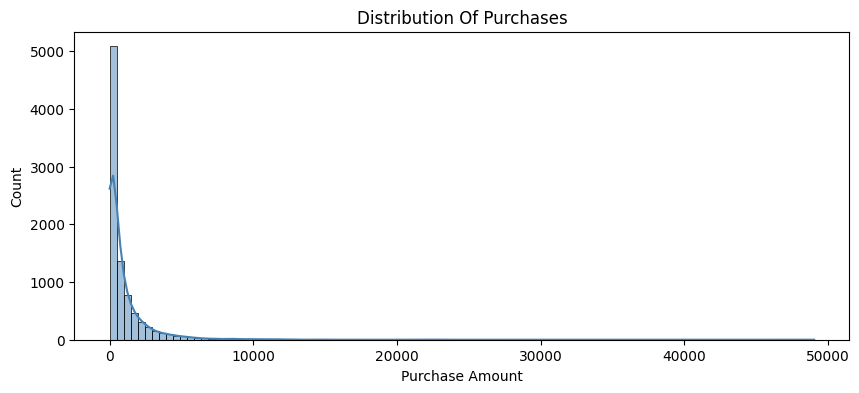

In [ ]:
#PLOT-1 Purchase Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.histplot(df['PURCHASES'],bins=100, kde=True, color='steelblue')
plt.title("Distribution Of Purchases")
plt.xlabel("Purchase Amount")
plt.show()

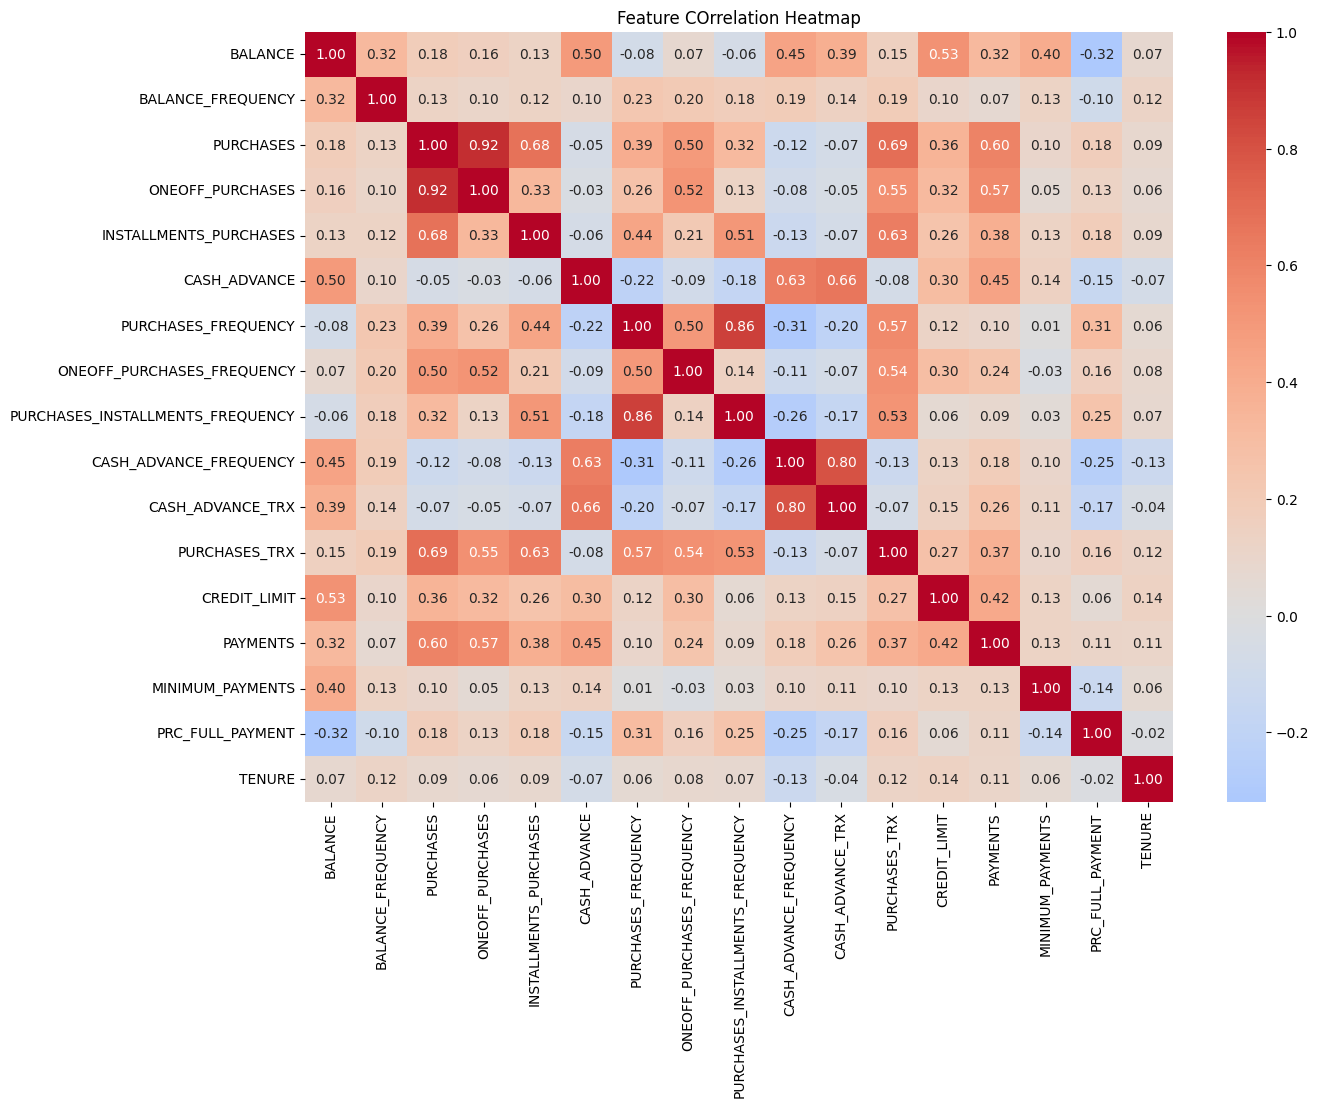

In [ ]:
#PLOT-2 Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt='.2f' , cmap = 'coolwarm' , center=0)
plt.title("Feature COrrelation Heatmap")
plt.show()

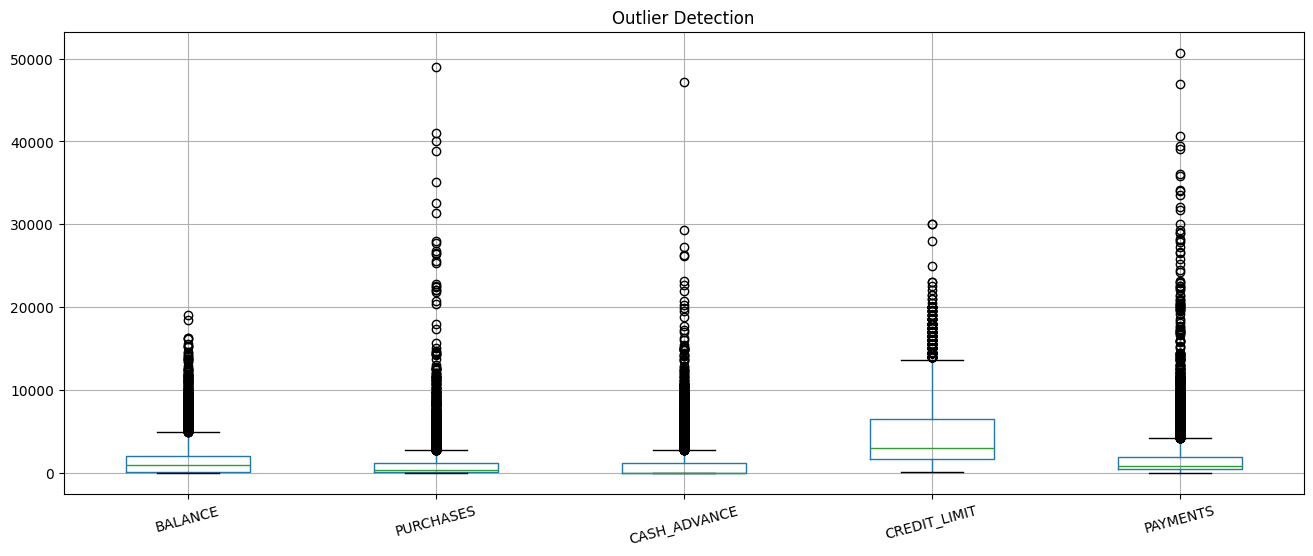

In [ ]:
#PLOT-3 Boxplot(spot outllier)
plt.figure(figsize=(16, 6))
df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']].boxplot()
plt.title('Outlier Detection')
plt.xticks(rotation=15)
plt.show()


### Preprocessing for clustering

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
scaler.fit_transform(df)
"Scaled shape:",df_scaled.shape

('Scaled shape:', (8950, 17))

In [ ]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters = k , random_state=42 , n_init=10)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

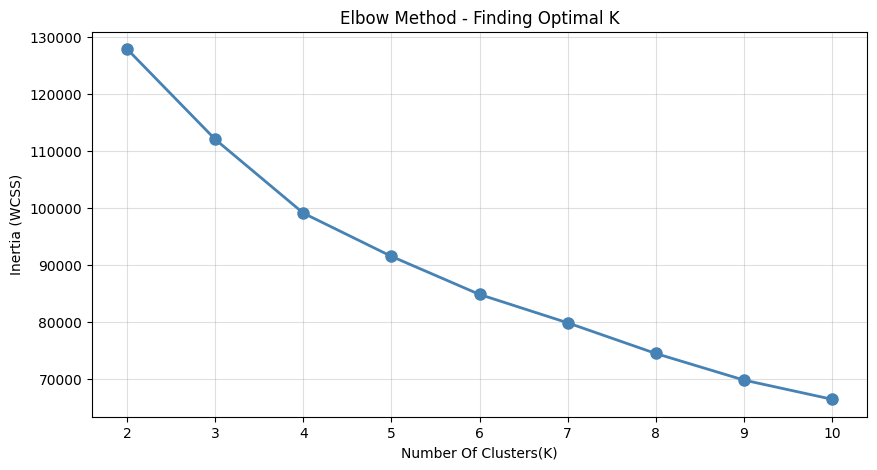

In [ ]:
#PLOT
plt.figure(figsize=(10,5))
plt.plot(list(K_range),inertias, 'o-' , color = 'steelblue',linewidth=2,markersize=8)
plt.xlabel("Number Of Clusters(K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method - Finding Optimal K")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.4)
plt.show()

In [ ]:
#Validate with Silhoute Scoring
from sklearn.metrics import silhouette_score

silhouette_scores=[]

for k in range(2,11):
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels,sample_size=2000,random_state=42)
    silhouette_scores.append(score)
    print(f"K={k} -> Silhoutte Score: {score:.4f}")

K=2 -> Silhoutte Score: 0.2157
K=3 -> Silhoutte Score: 0.2403
K=4 -> Silhoutte Score: 0.2004
K=5 -> Silhoutte Score: 0.1975
K=6 -> Silhoutte Score: 0.2054
K=7 -> Silhoutte Score: 0.2108
K=8 -> Silhoutte Score: 0.2252
K=9 -> Silhoutte Score: 0.2277
K=10 -> Silhoutte Score: 0.2224


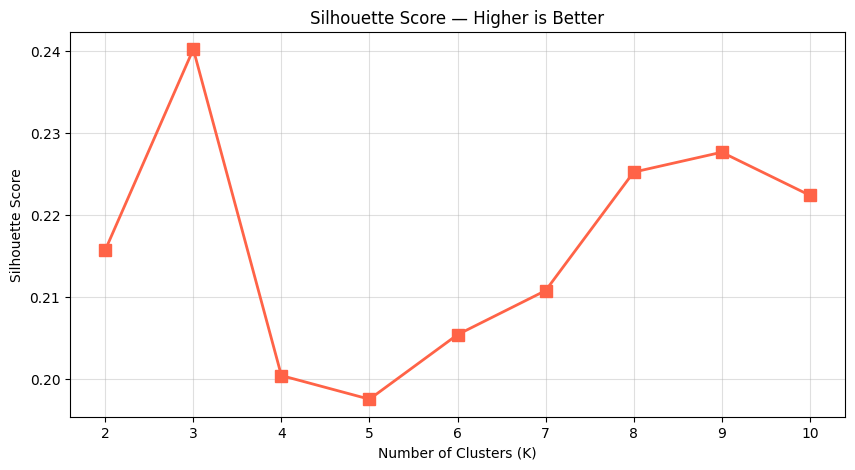

In [ ]:
# PLOT
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, 's-', color='tomato', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.4)
plt.show()

#k=3 -> 0.2403 (highest silhoutte score)
#k=4 -> 0.2004 (elbow point)
#K=3, it has the best score AND gives 3 meaningful, distinct customer groups

In [ ]:
#FINAL MODEL
kmeans = KMeans(n_clusters=3,random_state = 42, n_init=10)
df["Clusters"]=kmeans.fit_predict(df_scaled)

#See how many customers in each cluster
df["Clusters"].value_counts()

Clusters
1    6114
2    1561
0    1275
Name: count, dtype: int64

In [ ]:
#Profile the clusters
# Mean values of each feature per cluster
profile = df.groupby('Clusters').mean().round(2)
print(profile.T)  
# .T transposes so clusters are columns — easier to read


Clusters                                0        1        2
BALANCE                           2182.35   807.72  4023.79
BALANCE_FREQUENCY                    0.98     0.83     0.96
PURCHASES                         4187.02   496.06   389.05
ONEOFF_PURCHASES                  2664.00   247.27   252.33
INSTALLMENTS_PURCHASES            1523.49   249.11   136.80
CASH_ADVANCE                       449.75   339.00  3917.25
PURCHASES_FREQUENCY                  0.95     0.46     0.23
ONEOFF_PURCHASES_FREQUENCY           0.66     0.13     0.11
PURCHASES_INSTALLMENTS_FREQUENCY     0.74     0.34     0.15
CASH_ADVANCE_FREQUENCY               0.06     0.07     0.45
CASH_ADVANCE_TRX                     1.51     1.24    12.55
PURCHASES_TRX                       55.69     8.48     5.64
CREDIT_LIMIT                      7642.78  3267.02  6729.47
PAYMENTS                          4075.53   907.45  3053.94
MINIMUM_PAYMENTS                  1227.92   530.07  1765.20
PRC_FULL_PAYMENT                     0.3

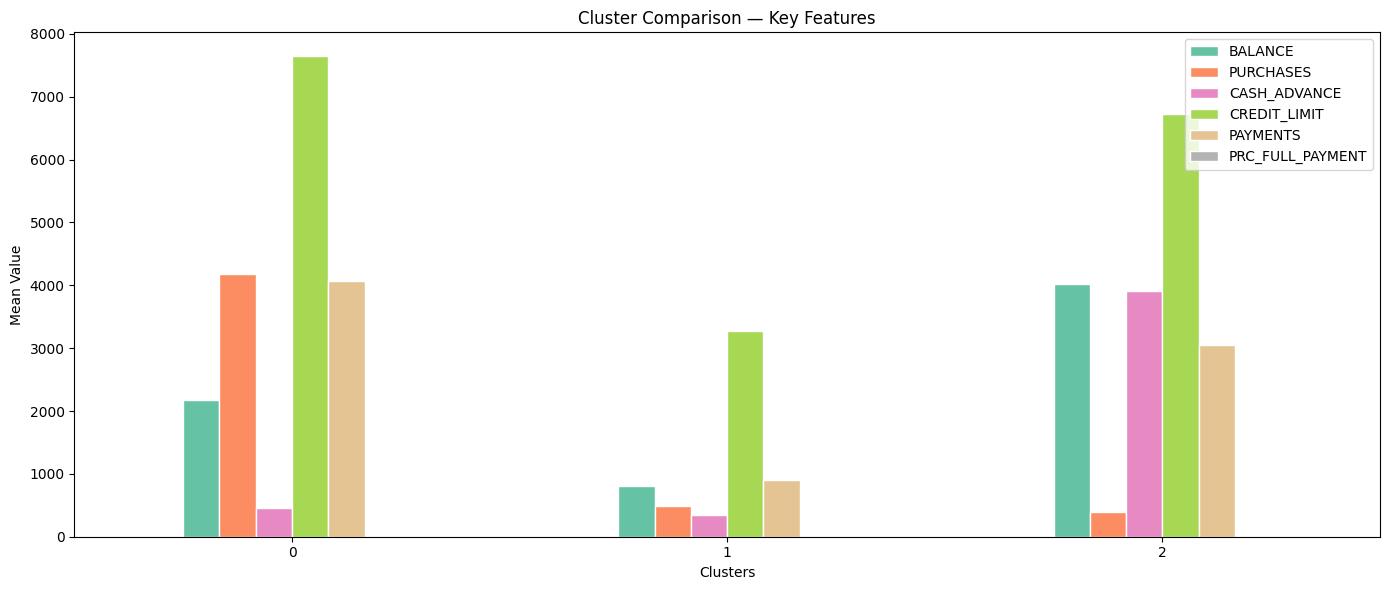

In [ ]:
# Compare key spending features across clusters
to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
                    'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']

profile[to_plot].plot(kind='bar', figsize=(14, 6), 
                                 colormap='Set2', edgecolor='white')
plt.title('Cluster Comparison — Key Features')
plt.xlabel('Clusters')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
#Since PRC_FULL_PAYMENT is a value between 0 and 1, 
# while other columns go up to 7000+. 
# So it's squished flat at the bottom of the chart. 
# Therefore ploting  PRC_FULL_PAYMENT separately as well.

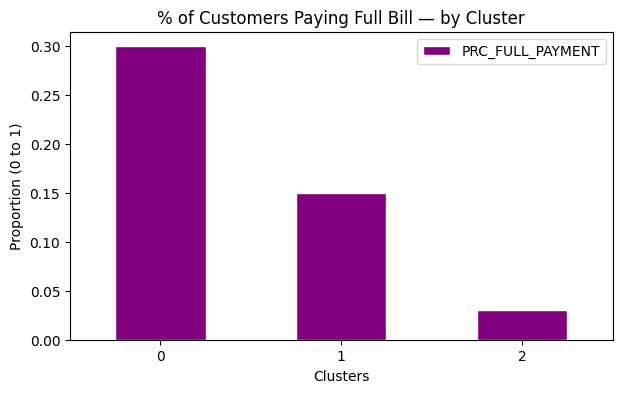

In [ ]:
profile[['PRC_FULL_PAYMENT']].plot(kind='bar', figsize=(7, 4), 
                                    color='purple', edgecolor='white')
plt.title('% of Customers Paying Full Bill — by Cluster')
plt.ylabel('Proportion (0 to 1)')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# The key columns as a table
profile[to_plot].round(2)


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Clusters,,,,,,
0,2182.35,4187.02,449.75,7642.78,4075.53,0.30
1,807.72,496.06,339.00,3267.02,907.45,0.15
2,4023.79,389.05,3917.25,6729.47,3053.94,0.03


In [ ]:
cluster_names = {0: 'Active Transactors', 
                 1: 'Inactive Users', 
                 2: 'Cash Advance Revolvers'}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)
print(df['Cluster_Name'].value_counts())
